In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Главная задача, которая перед нами стоит - оценить, стоит ли компаниям вкладываться в продвижение на ютубе, чтобы стать более привлекательными для соискателей, какой формат видео и тематики наиболее актуальны для позиционирования компаний в медиа.

Ранее вытянули данные по компаниям с сайта dream job + по видео с ютуба с упоминанием топовых бигтех компаний. В рамках данной задачи нас интересуют компании, по видеороликам которых у нас есть статистика, поэтому возьмём за основу датасет, где соединили данные по роликам на ютуб с рейтингами компаний через лефт джойн (по видео).

Данные о видео с упоминаниями компаний брались по топовым бигтех компаниям, поэтому как раз и берём лефт джойн, тк относительно компаний в нашем датасете, собранном через outer join, по которым у нас нет видеостатистики, мы не можем утверждать, что видео на ютубе нет, мы просто их не запрашивали (следовательно, не можем сравнивать рейтинги по категориям "компании с видео " против "компании без видео")

In [89]:
df_videos = pd.read_csv('df_videos_final.csv')
df_videos

,title_company,review,rec_share,review_cnts,review_name,emp_cnt,city,year_founded,industry,site,...,interest_score,tags,video_url,company_norm,company,rating,market,revenue,growth,market_num
0,Яндекс Крауд,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,2005.0,NaN,https://crowd.yandex.ru/,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
1,Яндекс,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,1997.0,"Информационные технологии, системная интеграци...",https://yandex.ru/jobs/,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
2,Яндекс Команда для бизнеса,"4,5",93%,6911.0,Очень хорошо,более 10000,Москва,NaN,NaN,NaN,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
3,Яндекс,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,1997.0,"Информационные технологии, системная интеграци...",https://yandex.ru/jobs/,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
4,Яндекс Крауд,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,2005.0,NaN,https://crowd.yandex.ru/,...,2.674206e+04,[],https://youtu.be/CuQ0iqA0vsI,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.934926e+07,"['путешествие', 'путешествия', 'россия', 'прир...",https://youtu.be/_R8mDUATWUM,tutu.ru,Tutu.ru,49,Traveltech,"14,00 *","+68,7%",1
6287,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.558669e+04,"['трум трум', 'шортс', 'балерина капучино', 'к...",https://youtu.be/2cLAiqlV9p4,tutu.ru,Tutu.ru,49,Traveltech,"14,00 *","+68,7%",1
6288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.281150e+13,"['pinkfong', 'family', 'kids', 'children', 'to...",https://youtu.be/0FXw3ezmly0,tutu.ru,Tutu.ru,49,Traveltech,"14,00 *","+68,7%",1
6289,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,9.572394e+08,"['роблокс мемы', 'роблокс мемы тик ток', 'робл...",https://youtu.be/lMuEB3D--H0,tutu.ru,Tutu.ru,49,Traveltech,"14,00 *","+68,7%",1


Наша целевая метрика - рейтинг компании, поэтому уберём все компании с отсутствием рейтинговых показателей (к ним относим сам рейтинг, процент порекомендовавших пользователей, оценку компании, выраженную словами), а также уберём дубликаты при наличии

In [90]:
mask = (
    df_videos['review'].isna()
    & df_videos['rec_share'].isna()
    & df_videos['review_name'].isna()
)

df_videos = df_videos[~mask]

df_videos = df_videos.drop_duplicates()
df_videos

,title_company,review,rec_share,review_cnts,review_name,emp_cnt,city,year_founded,industry,site,...,interest_score,tags,video_url,company_norm,company,rating,market,revenue,growth,market_num
0,Яндекс Крауд,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,2005.0,NaN,https://crowd.yandex.ru/,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
1,Яндекс,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,1997.0,"Информационные технологии, системная интеграци...",https://yandex.ru/jobs/,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
2,Яндекс Команда для бизнеса,"4,5",93%,6911.0,Очень хорошо,более 10000,Москва,NaN,NaN,NaN,...,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",https://youtu.be/We8bzlF1e2k,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
4,Яндекс Крауд,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,2005.0,NaN,https://crowd.yandex.ru/,...,2.674206e+04,[],https://youtu.be/CuQ0iqA0vsI,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
5,Яндекс,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,1997.0,"Информационные технологии, системная интеграци...",https://yandex.ru/jobs/,...,2.674206e+04,[],https://youtu.be/CuQ0iqA0vsI,yandex,Yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6254,ПОЗИТИВ,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,NaN,"Электроника, приборостроение, бытовая техника,...",NaN,...,5.316276e-02,[],https://youtu.be/Bc4xSYny-Lg,positive technologies,Positive Technologies,33,Cybersecurity,"24,50","+77,9%",1
6257,ПОЗИТИВ,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,NaN,"Электроника, приборостроение, бытовая техника,...",NaN,...,0.000000e+00,[],https://youtu.be/7g0eo_7Ppog,positive technologies,Positive Technologies,33,Cybersecurity,"24,50","+77,9%",1
6260,ПОЗИТИВ,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,NaN,"Электроника, приборостроение, бытовая техника,...",NaN,...,0.000000e+00,[],https://youtu.be/a05DlNCjkp0,positive technologies,Positive Technologies,33,Cybersecurity,"24,50","+77,9%",1
6263,ПОЗИТИВ,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,NaN,"Электроника, приборостроение, бытовая техника,...",NaN,...,1.133584e-01,[],https://youtu.be/HtG0nSkxPpk,positive technologies,Positive Technologies,33,Cybersecurity,"24,50","+77,9%",1


In [91]:
df_videos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1660 entries, 0 to 6266
Data columns (total 34 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title_company          1660 non-null   object 
 1   review                 1660 non-null   object 
 2   rec_share              1660 non-null   object 
 3   review_cnts            1660 non-null   float64
 4   review_name            1660 non-null   object 
 5   emp_cnt                1660 non-null   object 
 6   city                   1660 non-null   object 
 7   year_founded           1071 non-null   float64
 8   industry               1535 non-null   object 
 9   site                   1539 non-null   object 
 10  descr                  765 non-null    object 
 11  title_norm             1660 non-null   object 
 12  company_name           1660 non-null   object 
 13  title_video            1660 non-null   object 
 14  channel_title          1660 non-null   object 
 15  video_typ

Удалим неинформативные столбцы: ссылки (индивидуальны для каждого сайта и видео, не влияют на рейтинг), описание компании, год основания - много пропусков, также уберём title_company (название компании) и company (название группы компаний), тк их заменяют title_norm и company_norm, published_at, тк посмотреть, сколько дней прошло с момента публикации видео можно  по days_from_publication (и этот признак удобнее, тк в числовом формате)

In [92]:
df_videos = df_videos.drop(columns=['site', 'video_url', 'published_at', 'title_company', 'company', 'descr', 'year_founded'])
df_videos

,review,rec_share,review_cnts,review_name,emp_cnt,city,industry,title_norm,company_name,title_video,...,like_count,days_from_publication,interest_score,tags,company_norm,rating,market,revenue,growth,market_num
0,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
1,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
2,"4,5",93%,6911.0,Очень хорошо,более 10000,Москва,NaN,яндекс команда для бизнеса,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
4,"4,2",79%,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
5,"4,2",78%,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...","1095,00","+109,9%",10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6254,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Стажировка Positive Technologies 7: SSRF,...,1,3501,5.316276e-02,[],positive technologies,33,Cybersecurity,"24,50","+77,9%",1
6257,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,"Татьяна Зверева, Positive Technologies: Киберр...",...,0,1746,0.000000e+00,[],positive technologies,33,Cybersecurity,"24,50","+77,9%",1
6260,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Стажировка Positive Technologies 6: XXE,...,0,3514,0.000000e+00,[],positive technologies,33,Cybersecurity,"24,50","+77,9%",1
6263,"4,5",100%,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Positive Technologies технологическая стратеги...,...,7,1233,1.133584e-01,[],positive technologies,33,Cybersecurity,"24,50","+77,9%",1


Приведём столбцы, которые можно, в численный вид

In [93]:
df_videos['review'] = df_videos['review'].str.replace(',', '.').astype(float)
df_videos['rec_share'] = df_videos['rec_share'].str.replace('%', '').astype(int)
df_videos['revenue'] = df_videos['revenue'].str.replace(',', '.')
df_videos['revenue'] = df_videos['revenue'].str.replace(' *', '').astype(float)
df_videos['growth'] = df_videos['growth'].str.replace(',', '.')
df_videos['growth'] = df_videos['growth'].str.replace('%', '').astype(float)

In [94]:
df_videos.describe()

,review,rec_share,review_cnts,subscriber_count,view_count,like_count,days_from_publication,interest_score,rating,revenue,growth,market_num
count,1660.000000,1660.000000,1660.000000,1.660000e+03,1.660000e+03,1660.000000,1660.000000,1.660000e+03,1660.00000,1660.000000,1660.000000,1660.000000
mean,4.123735,79.819880,3534.470482,1.137294e+05,2.942755e+05,6809.146386,1239.419880,2.841456e+08,13.25000,252.935229,82.156386,3.309036
std,0.357327,11.426077,5880.130134,4.570221e+05,1.480423e+06,40030.716123,1001.447391,2.452494e+09,8.74187,309.306088,41.796554,2.929189
min,3.300000,48.000000,2.000000,0.000000e+00,3.000000e+00,0.000000,1.000000,0.000000e+00,1.00000,24.500000,15.600000,1.000000
25%,3.900000,76.000000,102.000000,8.990000e+02,4.167500e+02,5.000000,457.000000,2.706799e-01,6.00000,60.000000,50.900000,1.000000
50%,4.200000,79.000000,786.000000,5.760000e+03,3.365500e+03,48.000000,1057.000000,8.459119e+01,11.00000,120.640000,86.300000,2.000000
75%,4.300000,86.000000,4012.000000,3.520000e+04,4.451175e+04,687.000000,1718.000000,8.501243e+04,19.00000,283.300000,109.900000,4.000000
max,5.000000,100.000000,25779.000000,6.250000e+06,1.521890e+07,510886.000000,5658.000000,3.413136e+10,33.00000,1095.000000,197.200000,10.000000


Переведём просмотры и количество подписчиков в тысячи

In [95]:
df_videos['view_count'] = df_videos['view_count'] / 1000
df_videos['subscriber_count'] = df_videos['subscriber_count'] / 1000
df_videos

,review,rec_share,review_cnts,review_name,emp_cnt,city,industry,title_norm,company_name,title_video,...,like_count,days_from_publication,interest_score,tags,company_norm,rating,market,revenue,growth,market_num
0,4.2,79,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
1,4.2,78,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
2,4.5,93,6911.0,Очень хорошо,более 10000,Москва,NaN,яндекс команда для бизнеса,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
4,4.2,79,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
5,4.2,78,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6254,4.5,100,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Стажировка Positive Technologies 7: SSRF,...,1,3501,5.316276e-02,[],positive technologies,33,Cybersecurity,24.5,77.9,1
6257,4.5,100,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,"Татьяна Зверева, Positive Technologies: Киберр...",...,0,1746,0.000000e+00,[],positive technologies,33,Cybersecurity,24.5,77.9,1
6260,4.5,100,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Стажировка Positive Technologies 6: XXE,...,0,3514,0.000000e+00,[],positive technologies,33,Cybersecurity,24.5,77.9,1
6263,4.5,100,2.0,Очень хорошо,меньше 100,Россия,"Электроника, приборостроение, бытовая техника,...",позитив,Positive Technologies,Positive Technologies технологическая стратеги...,...,7,1233,1.133584e-01,[],positive technologies,33,Cybersecurity,24.5,77.9,1


Кажется, что рейтинг, сформированный по оценкам всего 2 людей не очень справедлив, давайте оставим компании, у которых хотя бы 100 оценок

In [96]:
df_videos = df_videos[df_videos['review_cnts'] >= 100]
df_videos

,review,rec_share,review_cnts,review_name,emp_cnt,city,industry,title_norm,company_name,title_video,...,like_count,days_from_publication,interest_score,tags,company_norm,rating,market,revenue,growth,market_num
0,4.2,79,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
1,4.2,78,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
2,4.5,93,6911.0,Очень хорошо,более 10000,Москва,NaN,яндекс команда для бизнеса,Yandex,Ты все еще хочешь работать в Яндекс?,...,2525,325,9.962168e+06,"['осознанная меркантильность', 'антон назаров'...",yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
4,4.2,79,3471.0,Очень хорошо,более 10000,Москва,NaN,яндекс крауд,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
5,4.2,78,4189.0,Очень хорошо,более 10000,Москва,"Информационные технологии, системная интеграци...",яндекс,Yandex,"Говорят, что в Яндексе мало платят. Это правда...",...,1395,978,2.674206e+04,[],yandex,1,"Экосистема, Social Networks, Edtech, Fintech, ...",1095.0,109.9,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5947,4.2,80,634.0,Очень хорошо,1000-9999,Москва,"Информационные технологии, системная интеграци...",крок,Крок,5 главных шагов для начинающих дизайнеров!,...,2408,898,3.584764e+05,"['Skillbox', 'Skillbox дизайн', 'дизайн', 'диз...",крок,30,IT-услуги,32.0,26.9,1
5949,4.2,80,634.0,Очень хорошо,1000-9999,Москва,"Информационные технологии, системная интеграци...",крок,Крок,А как вы себе представляете программистов?😅,...,73,1205,6.403132e+02,"['Программирование', 'АйТи', 'юмор']",крок,30,IT-услуги,32.0,26.9,1
5951,4.2,80,634.0,Очень хорошо,1000-9999,Москва,"Информационные технологии, системная интеграци...",крок,Крок,Предложения КРОК в области финансирования ИТ-п...,...,0,4975,0.000000e+00,"['ИТ', 'IT', 'КРОК', 'корпоративные', 'приложе...",крок,30,IT-услуги,32.0,26.9,1
5953,4.2,80,634.0,Очень хорошо,1000-9999,Москва,"Информационные технологии, системная интеграци...",крок,Крок,Летняя ИТ-школа КРОК: ИТ-рекрутинг,...,5,688,7.582504e-02,[],крок,30,IT-услуги,32.0,26.9,1


На всякий случай дадим небольшую сноску, последние столбцы - данные о компаниях от smart ranking [ссылка на список](https://smartranking.ru/ru/ranking/big-tech/#:~:text=Table_title:%20%D0%A0%D0%B5%D0%B9%D1%82%D0%B8%D0%BD%D0%B3%20%D0%BA%D1%80%D1%83%D0%BF%D0%BD%D0%B5%D0%B9%D1%88%D0%B8%D1%85%20%D1%82%D0%B5%D1%85%D0%BD%D0%BE%D0%BB%D0%BE%D0%B3%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B8%D1%85%20%D0%BA%D0%BE%D0%BC%D0%BF%D0%B0%D0%BD%D0%B8%D0%B9%20BigTech%20100%2C%D1%81%D0%B5%D1%80%D0%B2%D0%B8%D1%81%D1%8B%20%D0%BE%D1%82%20Ozon%20%D0%91%D0%B0%D0%BD%D0%BA%2C%20Ozon%20Travel.%20%7C)

rating - положение компании в рейтинге
revenue - выручка бизнеса за 24 год
growth - динамика роста выручки с 22 по 24 год
market_num - количество рынков, на которых работает компания

[Взяли за основу для расчета interest_score](https://habr.com/en/companies/vdsina/articles/533080/)

In [97]:
df_1 = df_videos.groupby(['title_norm', 'review', 'rec_share', 'review_cnts', 'review_name', 'emp_cnt'])[['subscriber_count', 'view_count', 'like_count', 'interest_score']].mean().reset_index()
df_1

,title_norm,review,rec_share,review_cnts,review_name,emp_cnt,subscriber_count,view_count,like_count,interest_score
0,1с архитектор бизнеса,4.3,86,102.0,Очень хорошо,100-499,47.658512,71.639610,1729.146341,2.229462e+06
1,headhunter,4.5,94,240.0,Очень хорошо,1000-9999,22.852675,61.052600,2416.975000,5.456301e+06
2,iteco,4.5,90,2044.0,Очень хорошо,более 10000,22.633541,29.925459,518.729730,4.831536e+05
3,lamoda,4.0,76,4260.0,Очень хорошо,1000-9999,74.942952,582.846262,11707.476190,4.954076e+08
4,ozon,4.5,93,11034.0,Очень хорошо,более 10000,25.236814,178.053163,2766.232558,8.884620e+07
5,ozon (ип проценко валерия александровна),3.7,78,648.0,Хорошо,меньше 100,25.236814,178.053163,2766.232558,8.884620e+07
6,rwb (wildberries & russ),3.7,68,14478.0,Хорошо,более 10000,44.900209,550.048744,10821.232558,5.121089e+08
7,softline,4.2,82,983.0,Очень хорошо,более 10000,39.348638,1.730702,58.595745,6.324153e+01
8,vk,4.2,78,1577.0,Очень хорошо,более 10000,85.355409,316.385727,8947.136364,4.330094e+08
9,авито,4.2,80,1031.0,Очень хорошо,более 10000,189.083136,623.512932,17970.954545,5.951218e+08


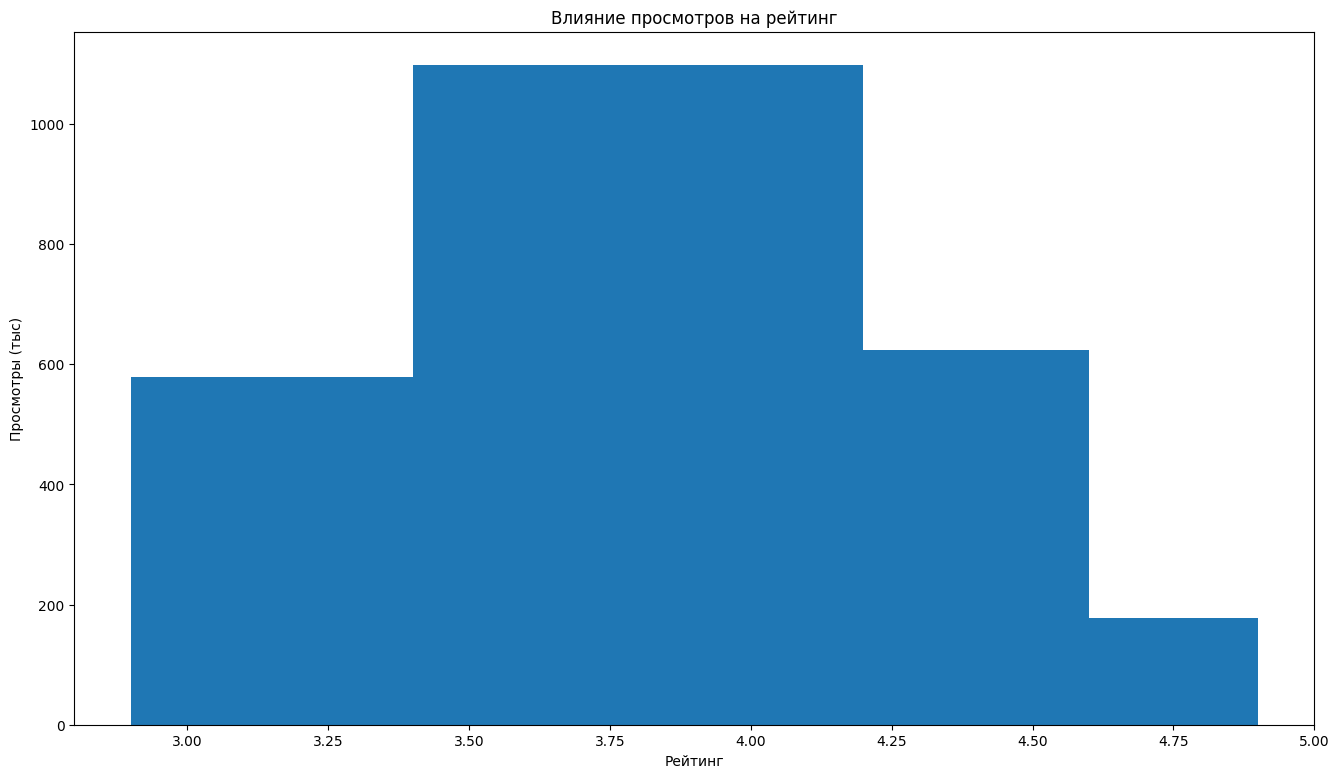

In [98]:
plt.figure(figsize=(16, 9))
plt.bar(df_1['review'], df_1['view_count'])
plt.xlabel('Рейтинг')
plt.ylabel('Просмотры (тыс)')
plt.title('Влияние просмотров на рейтинг')
plt.show()

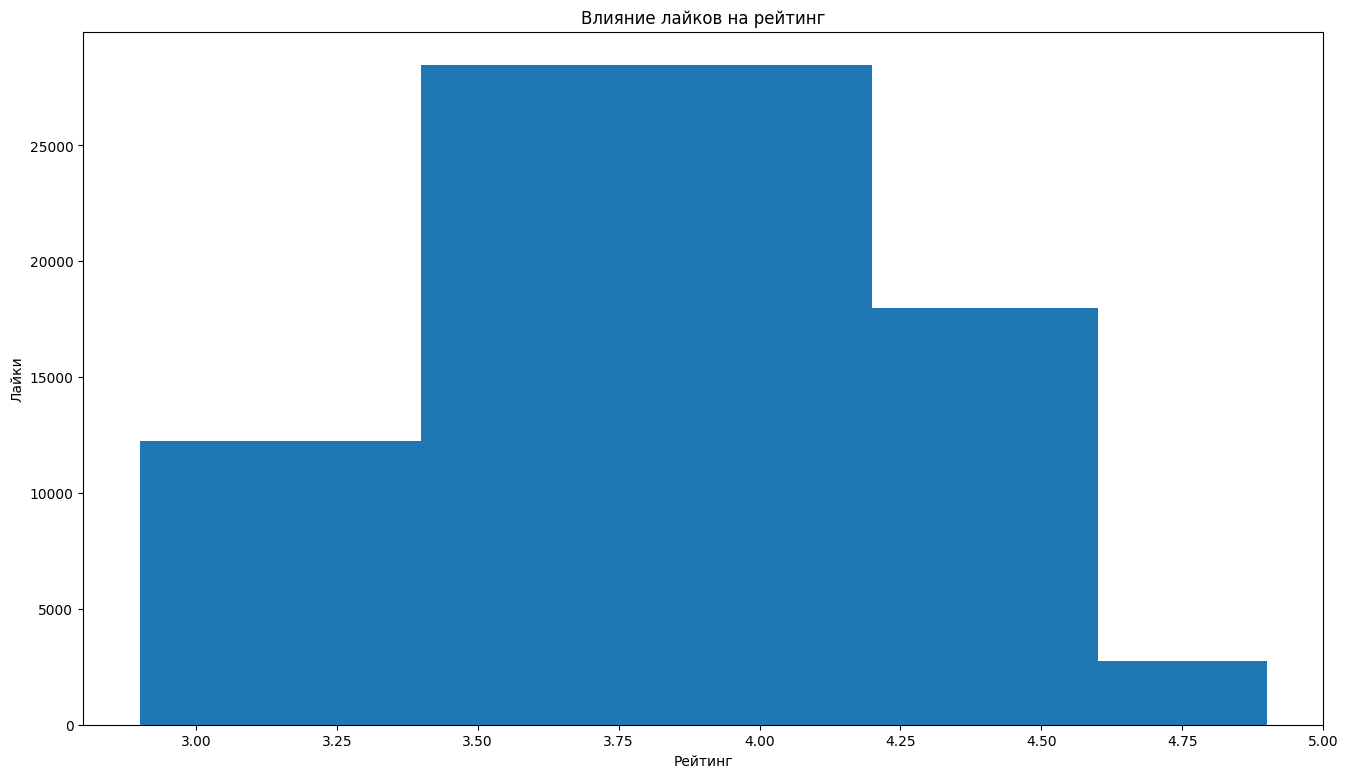

In [99]:
plt.figure(figsize=(16, 9))
plt.bar(df_1['review'], df_1['like_count'])
plt.xlabel('Рейтинг')
plt.ylabel('Лайки')
plt.title('Влияние лайков на рейтинг')
plt.show()

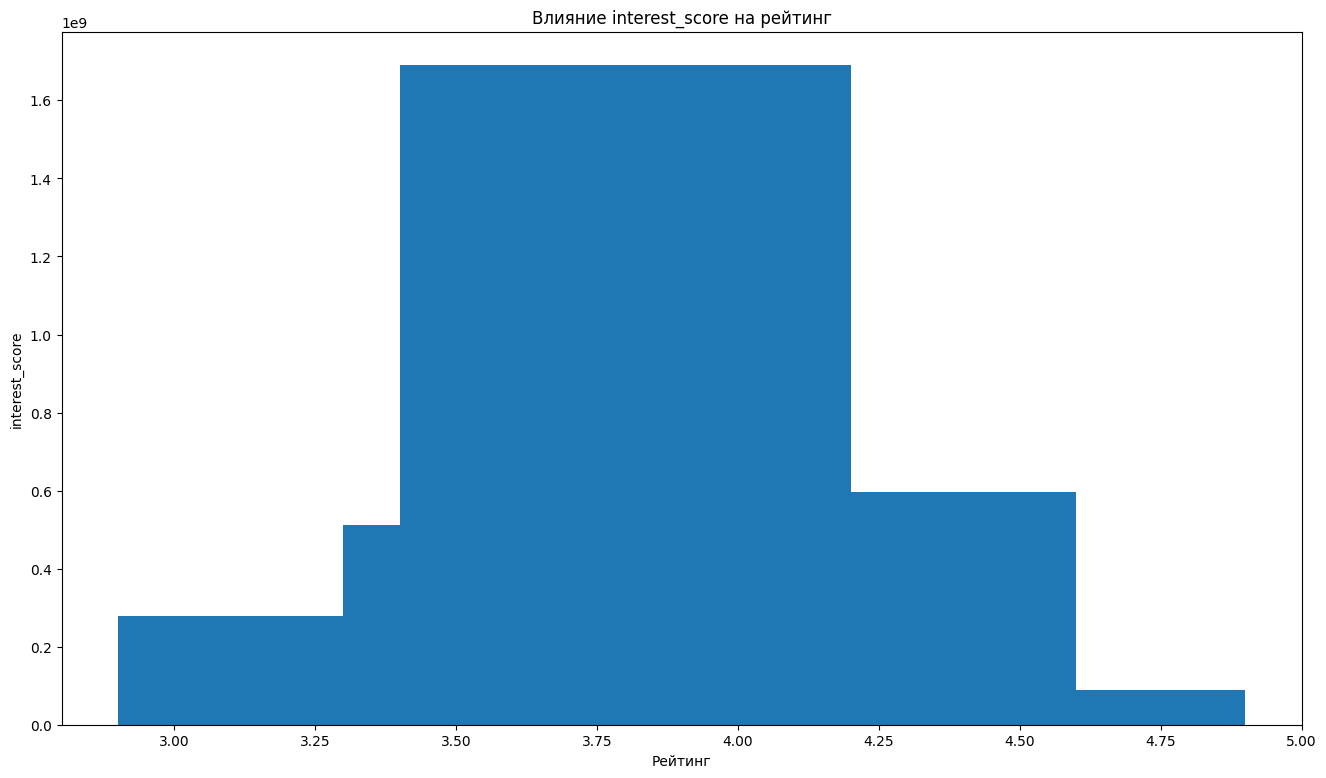

In [101]:
plt.figure(figsize=(16, 9))
plt.bar(df_1['review'], df_1['interest_score'])
plt.xlabel('Рейтинг')
plt.ylabel('interest_score')
plt.title('Влияние interest_score на рейтинг')
plt.show()

Посмотрели корреляцию показателей, отвечающих за популярность видео с рейтингом компании как работадателя. Какие можно сделать выводы: просмотры не имеют сильного влияния на рейтинг, если не считать компании с самым топовым рейтингом, то график практически симметричен (относительно просмотров для хорошего и плохого рейтинга)

В случае с лайками и interest_score видим перекос, эти показатели в среднем, лучше у компаний с рейтингом выше среднего, следовательно, наличие упоминаний компании в медиасфере влияет на рейтинг компании, и при выстраивании стратегии продвижения, стоит акцентировать внимание не на большом количестве просмотров (охватах в целом), а на высокой вовлечённости (лайки и совокупная метрика - interest_score)



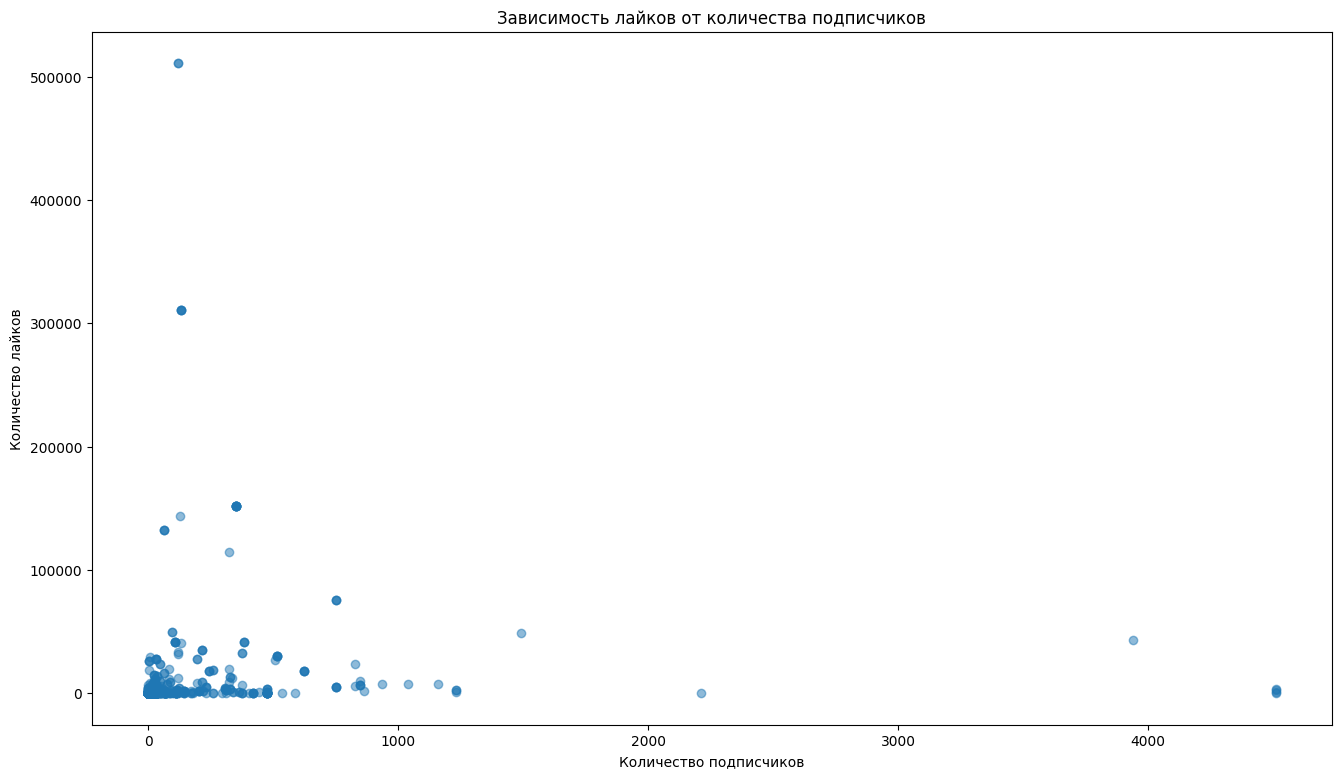

In [102]:
plt.figure(figsize=(16, 9))
plt.scatter(df_videos['subscriber_count'], df_videos['like_count'], alpha=0.5)
plt.xlabel('Количество подписчиков')
plt.ylabel('Количество лайков')
plt.title('Зависимость лайков от количества подписчиков')
plt.show()

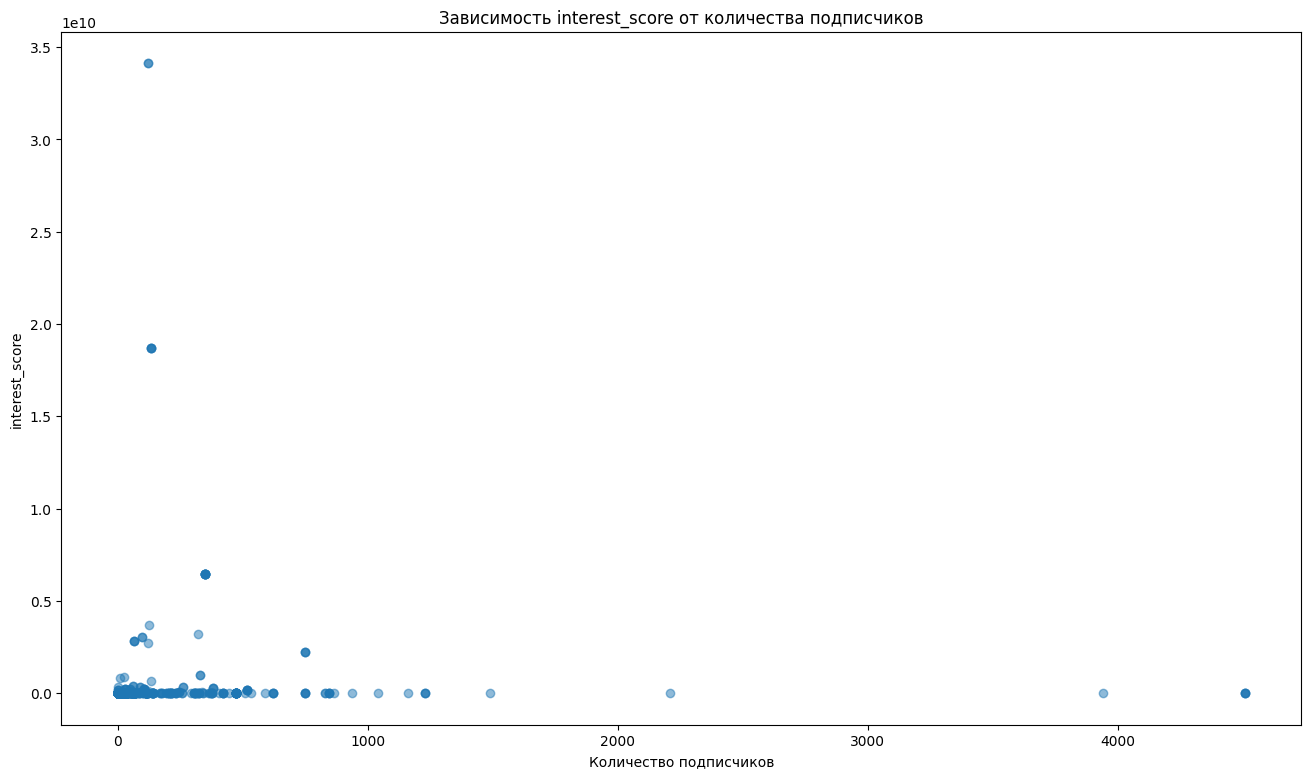

In [103]:
plt.figure(figsize=(16, 9))
plt.scatter(df_videos['subscriber_count'], df_videos['interest_score'], alpha=0.5)
plt.xlabel('Количество подписчиков')
plt.ylabel('interest_score')
plt.title('Зависимость interest_score от количества подписчиков')
plt.show()

Количество подписчиков больше влияет на лайки, чем на interest score, но в любом случае большую вовлечённость показывают маленькие каналы, поэтому при продвижении стоит сфокусироваться на них